# Preparação de Dados e Avaliação de Modelos

Notebook abrangente sobre técnicas essenciais de pré-processamento de dados e métricas de avaliação de modelos de machine learning.

In [1]:
# Preparação de Dados e Avaliação de Modelos

## 1. Importação de Bibliotecas

Importando as bibliotecas necessárias para manipulação de dados, cálculos numéricos e visualização.

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

## 2. Tratamento de Valores Faltantes (Missing Values)

### Método: dropna()

Removendo linhas com valores nulos/ausentes do DataFrame.

In [3]:
# Criando um DataFrame de exemplo com um valor NA
df = pd.DataFrame({
    'Nome': ['Ana', 'Bruno', 'Carlos'],
    'Idade': [28, np.nan, 34],
    'Sexo': ['F', 'M', 'M']
})
print(df)

     Nome  Idade Sexo
0     Ana   28.0    F
1   Bruno    NaN    M
2  Carlos   34.0    M


In [4]:
df.dropna()

,Nome,Idade,Sexo
0,Ana,28.0,F
2,Carlos,34.0,M


In [5]:
df

,Nome,Idade,Sexo
0,Ana,28.0,F
1,Bruno,NaN,M
2,Carlos,34.0,M


In [6]:
df.dropna(inplace=True)

In [7]:
df

,Nome,Idade,Sexo
0,Ana,28.0,F
2,Carlos,34.0,M


## RSME e MAPE


## 3. Métricas de Avaliação de Modelos

### 3.1 RMSE (Root Mean Squared Error) e MAPE (Mean Absolute Percentage Error)

Cálculo das principais métricas para avaliação de modelos de regressão.

In [8]:
# RMSE sem o sckit-learn
# Valores reais
reais = [100000, 150000, 200000, 250000, 300000]
 
# Valores previstos pelo modelo
prev = [95000, 142000, 210000, 245000, 315000]
 
# Cálculo do RMSE
diferencas = [r - p for r, p in zip(reais, prev)]
quadrados_das_diferencas = [d ** 2 for d in diferencas]
mse = np.mean(quadrados_das_diferencas)
rmse = np.sqrt(mse)
 
print(f"MSE: {mse}\nRMSE: {rmse}")

MSE: 87800000.0
RMSE: 9370.165420097983


**RMSE (Sem scikit-learn):**

In [9]:
# RMSE com scikit-learn and built-in functions
from sklearn.metrics import mean_squared_error

# Valores reais
reais = [100000, 150000, 200000, 250000, 300000]
 
# Valores previstos pelo modelo
prev = [95000, 142000, 210000, 245000, 315000]

mse = mean_squared_error(reais, prev)
rmse = np.sqrt(mse)

print(f"MSE: {mse}\nRMSE: {rmse}")

MSE: 87800000.0
RMSE: 9370.165420097983


**RMSE (Com scikit-learn):**

In [10]:
# MAPE sem scikit-learn 

# Valores reais
reais = [100000, 150000, 200000, 250000, 300000]
 
# Valores previstos pelo modelo
prev = [95000, 142000, 210000, 245000, 315000]

# Cálculo do MAPE
diferencas = [r - p for r, p in zip(reais, prev)]
percentuais_de_erro = [abs(d / r) for d, r in zip(diferencas, reais)]
mape = np.mean(percentuais_de_erro) * 100
print(f"MAPE: {mape}%")

MAPE: 4.466666666666667%


**MAPE (Sem scikit-learn):**

In [11]:
# MAPE com scikit-learn
from sklearn.metrics import mean_absolute_percentage_error

# Valores reais
reais = [100000, 150000, 200000, 250000, 300000]
 
# Valores previstos pelo modelo
prev = [95000, 142000, 210000, 245000, 315000]

mape = mean_absolute_percentage_error(reais, prev) 
print(f"MAPE: {mape}%, vezes 100 = {mape * 100}%")

MAPE: 0.04466666666666667%, vezes 100 = 4.466666666666667%


**MAPE (Com scikit-learn):**

In [12]:
#Imputação de valores faltantes
from sklearn.impute import SimpleImputer

# Dados com valores ausentes
dados = np.array([[1, 2, 3, np.nan],
                  [4, np.nan, 6, 7],
                  [8, 2, 5, 7],
                  [8, 11, 10, 10]])

# Imputação com a média das colunas
imputador=SimpleImputer(missing_values=np.nan, strategy='mean')
dados_imputados = imputador.fit_transform(dados)

print(f"Dados após imputação: {dados_imputados}")



Dados após imputação: [[ 1.  2.  3.  8.]
 [ 4.  5.  6.  7.]
 [ 8.  2.  5.  7.]
 [ 8. 11. 10. 10.]]


## 4. Imputação de Valores Faltantes

Substituindo valores ausentes por meio de estratégias como média e valor mais frequente.

In [13]:
# Imputação com outros parâmetros

imputador = SimpleImputer(strategy='most_frequent')

dados_imp_most_frequent = imputador.fit_transform(dados)

dados_imp_most_frequent

array([[ 1.,  2.,  3.,  7.],
       [ 4.,  2.,  6.,  7.],
       [ 8.,  2.,  5.,  7.],
       [ 8., 11., 10., 10.]])

**Imputação com Estratégia de Valor Mais Frequente:**

In [14]:
# Identificação de Outliers

dados = np.array([1, 2, 3, 4, 5,6,7,8,9, 100,100])
dados


array([  1,   2,   3,   4,   5,   6,   7,   8,   9, 100, 100])

## 5. Identificação e Tratamento de Outliers

Detecção de valores anômalos usando o método do IQR (Intervalo Interquartílico).

In [15]:
# Quartis e IQR
Q1 = np.percentile(dados, 25)
Q3 = np.percentile(dados, 75)
IQR = Q3 - Q1
print(f"1° Quartil (Q1): {Q1}, 3° Quartil (Q3): {Q3}, IQR: {IQR}")

1° Quartil (Q1): 3.5, 3° Quartil (Q3): 8.5, IQR: 5.0


**Cálculo dos Quartis e IQR:**

In [16]:
# Limite inferior e superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR
print(f"Limite Inferior: {limite_inferior}, Limite Superior:{limite_superior}")

Limite Inferior: -4.0, Limite Superior:16.0


**Cálculo dos Limites Inferior e Superior:**

In [17]:
outliers = np.where((dados < limite_inferior) | (dados > limite_superior))[0]
outliers

array([ 9, 10])

**Identificação dos Outliers:**

In [18]:
dados[outliers]

array([100, 100])

In [19]:
# Remoção de Outliers
np.delete(dados, outliers)

array([1, 2, 3, 4, 5, 6, 7, 8, 9])

**Remoção dos Outliers:**

In [20]:
#Lista em python

lista = [10,20,30,40,50]
lista

[10, 20, 30, 40, 50]

## 6. Conceitos de Listas em Python

Revisão de operações básicas com listas: indexação, acesso de elementos e operações comuns.

**Acesso a Elementos da Lista:**

In [21]:
lista[0],lista[1]

(10, 20)

In [22]:
lista[5]

IndexError: list index out of range

**Acesso com Índices Negativos:**

In [ ]:
lista[-1],lista[-2]

(50, 40)

**Comprimento da Lista:**

In [ ]:
len(lista)

5

## 7. Normalização de Dados

Escalonamento de dados para intervalo [0, 1] utilizando normalização por valor máximo.

In [ ]:
# Normalização de Dados de uma lista

from sklearn.preprocessing import normalize

dados = np.array([2, 3, 5,6,7,4,8, 7,6,0])
dados


array([2, 3, 5, 6, 7, 4, 8, 7, 6, 0])

**Dados Normalizados:**

In [ ]:
dados_normalizados = normalize([dados],norm='max')
dados_normalizados

array([[0.25 , 0.375, 0.625, 0.75 , 0.875, 0.5  , 1.   , 0.875, 0.75 ,
        0.   ]])

## 8. Padronização de Dados

In [ ]:
from sklearn.preprocessing import StandardScaler

dados = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])
dados

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [ ]:
padronizador = StandardScaler()
dados_padronizados = padronizador.fit_transform(dados)
dados_padronizados

array([[-1.22474487, -1.22474487, -1.22474487],
       [ 0.        ,  0.        ,  0.        ],
       [ 1.22474487,  1.22474487,  1.22474487]])

**Codificação com One-hot enconding e label encoding:**

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [ ]:
dados_categoricos = np.array(['A', 'B', 'C', 'A', 'B'])
dados_categoricos

array(['A', 'B', 'C', 'A', 'B'], dtype='<U1')

In [ ]:
codific_one_hot = OneHotEncoder()
dados_one_hot = codific_one_hot.fit_transform(dados_categoricos.reshape(-1,1))
dados_one_hot.toarray()

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 1., 0.]])

In [ ]:
codific_label = LabelEncoder()
dados_label = codific_label.fit_transform(dados_categoricos)
dados_label

array([0, 1, 2, 0, 1])

# 9. Cálculo das métricas de acuráci,precisão revocação e f1-score

**Exemplo relaciona a testes médicos de COVID-19**

- **Verdadeiro Positivo (VP):** quando o teste indica **positivo para COVID-19** e a pessoa **realmente está doente**.  
- **Verdadeiro Negativo (VN):** quando o teste indica **negativo** e a pessoa **realmente não está doente**.  
- **Falso Positivo (FP):** quando o teste indica **positivo**, mas a pessoa **não está doente**.  
- **Falso Negativo (FN):** quando o teste indica **negativo**, mas a pessoa **está doente**.  

Essas quatro situações formam a base da **matriz de confusão** e são usadas para calcular métricas como acurácia, precisão, revocação (recall) e F1-score.  

Resumo dos números no exemplo:  
  
Pessoas Infectadas (Real): 200  
  
Pessoas não infectadas (Real): 800  

Verdadeiros Positivos: 150  
  
Verdadeiros Negativos: 700  
  
Falsos Positivos: 50  
  
Falsos Negativos: 50  
  
  

In [ ]:
total = 1000
vp = 150
vn = 700
fp = 50
fn = 100

## Acurácia

In [ ]:
acuracia = (vp + vn) / total
acuracia

0.85

## Precisão

In [ ]:
precisao = vp / (vp + fp)
precisao

0.75

## Revocação

In [ ]:
revocacao = vp / (vp + fn)
revocacao

0.6

## F1-Score

In [ ]:
f1_score = 2 * (precisao * revocacao) / (precisao + revocacao)
f1_score

0.6666666666666665

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_real = [1,0,1,0]

y_pred = [0,1,1,1]

In [24]:
# Métricas de avaliação
acuracia = accuracy_score(y_real, y_pred)
precisao = precision_score(y_real, y_pred)
revocacao = recall_score(y_real, y_pred)
f1 = f1_score(y_real, y_pred)

print(f"Acurácia: {acuracia}\nPrecisão: {precisao}\nRevocação: {revocacao}\nF1 Score: {f1}")


Acurácia: 0.25
Precisão: 0.3333333333333333
Revocação: 0.5
F1 Score: 0.4


# Classification Report

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_real, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      0.50      0.40         2

    accuracy                           0.25         4
   macro avg       0.17      0.25      0.20         4
weighted avg       0.17      0.25      0.20         4



# Matriz de Confusão

**Modelo para classificar imagens de cachorro**

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [34]:
y_real_animais = ['gato', 'cachorro', 'gato', 'cachorro']
y_pred_animais = ['gato', 'cachorro', 'cachorro', 'cachorro']

In [35]:
confusion_matrix(y_real_animais, y_pred_animais)

array([[2, 0],
       [1, 1]])

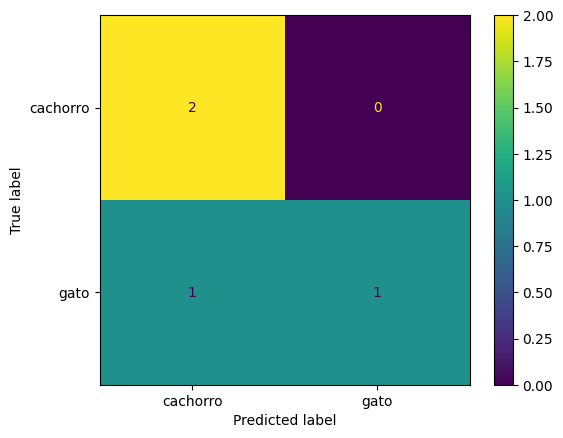

In [37]:
conf_mtrx = confusion_matrix(y_real_animais, y_pred_animais,labels=['cachorro', 'gato'])
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mtrx, display_labels=['cachorro', 'gato'])
disp.plot()
plt.show()

In [38]:
conf_mtrx = confusion_matrix(y_real_animais, y_pred_animais).ravel()
conf_mtrx


array([2, 0, 1, 1])

In [39]:
tp,fn,fp,tn = confusion_matrix(y_real_animais, y_pred_animais).ravel()
tp,fn,fp,tn


(np.int64(2), np.int64(0), np.int64(1), np.int64(1))